# 08 - DE sink: background, CMB and P(k)

accDM with `acc_de_sink` off and on, and both against ΛCDM, over a mass scan with the default kick
η = 10¹¹ GeV/m. The sink is a w = −1 component that pays the daughters' kick energy, so it is larger in
the past: ρ_de_acc(a) = η f_acc ρ_cdm,0 J(a), with J(0) ≈ 471 for κ = 12.1, a_t = 0.133. It vanishes
today, so it changes the expansion history only before and during the transition.

`FIX` sets what is held fixed: `'100*theta_s'` (H0 is solved for, closest to what a fit sees) or
`'H0'` (then the peak shift from the changed sound horizon dominates ΔC_ℓ).

**Result** (f_acc = 0.2, θ_s fixed). The sink matters only for light, strongly kicked daughters. Its peak
density is Ω_de_acc ≈ 0.2 at 10¹³ GeV and ≈ 24 at 10¹¹ GeV (in units of today's critical density).
Switching it on changes TT by at most 0.1% at 10¹³ GeV, 1% at 10¹² GeV and 8% at 10¹¹ GeV, and lowers
the H0 that matches θ_s by 0.01, 0.14 and 1.3 km/s/Mpc. From 10¹⁶ GeV up it is negligible
(Ω_de_acc ≤ 2·10⁻⁴). The 7·10⁻⁴ TT change at 10¹⁷ GeV, absent at 10¹⁶ and 10¹⁸ GeV, is not the sink (10×
smaller there than at 10¹⁶ GeV) but the kind of numerical jump seen in notebooks 12 and 16–18.

Model: f_acc = 0.2, κ = 12.1, a_t = 0.133, default daughter grid. Cached in `08_cache.pkl`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import A_T, RunCache, accdm_params, lcdm_params, ok, status, show, plot_style

plot_style()

FIX = '100*theta_s'                          # or 'H0'
FIXED = {'100*theta_s': {'100*theta_s': 1.041783}, 'H0': {'H0': 67.32}}[FIX]
MASSES = [1e10, 1e11, 1e12, 1e13, 1e16, 1e17, 1e18]      # GeV
F_ACC = 0.2
LMAX = 2500
K = np.logspace(-4, np.log10(5.0), 300)      # 1/Mpc
OUTPUT = {'output': 'tCl,pCl,lCl,mPk', 'lensing': 'yes', 'l_max_scalars': LMAX, 'P_k_max_1/Mpc': 10.0,
          'z_max_pk': 0.0, 'gauge': 'synchronous', **FIXED}
BG_COLS = ('z', 'H [1/Mpc]', '(.)rho_crit', '(.)rho_cdm', '(.)rho_acc_cdm', '(.)rho_ncdm[1]',
           '(.)rho_lambda', '(.)rho_de_acc', '(.)rho_b', '(.)rho_g')


def extract(cosmo):
    bg = cosmo.get_background()
    cl = cosmo.lensed_cl(LMAX)
    return {'bg': {k: np.asarray(bg[k]) for k in BG_COLS if k in bg},
            **{s: np.asarray(cl[s])[2:] for s in ('tt', 'ee', 'te', 'pp')},
            'pk': np.array([cosmo.pk(k, 0.0) for k in K]),
            **cosmo.get_current_derived_parameters(['h', '100*theta_s', 'sigma8'])}


def fixed(p):
    """Drop Planck's H0 when theta_s is held fixed instead."""
    return {k: v for k, v in p.items() if k != 'H0' or FIX == 'H0'}


def params(mass, sink):
    return fixed(accdm_params(F_ACC, mass, acc_de_sink='yes' if sink else 'no', **OUTPUT))


cache = RunCache('08_cache.pkl', extract=extract, workers=4)
jobs = [fixed(lcdm_params(**OUTPUT))] + [params(m, s) for m in MASSES for s in (False, True)]
out = cache.many(jobs)
runs = {'lcdm': out[0], **{(m, s): r for (m, s), r in zip([(m, s) for m in MASSES for s in (False, True)], out[1:])}}
for key, r in runs.items():
    if not ok(r):
        print(key, status(r))
done = [m for m in MASSES if ok(runs[(m, False)]) and ok(runs[(m, True)])]

15 new CLASS runs in 250 s


Sanity: at the heaviest mass the sink is negligible, so switching it on must change nothing.

In [2]:
off, on = runs[(max(done), False)], runs[(max(done), True)]
d = max(np.max(np.abs(on['tt']/off['tt'] - 1)), np.max(np.abs(on['pk']/off['pk'] - 1)))
print('m = {:.0e} GeV: max relative change of TT and P(k) from the sink = {:.1e}'.format(max(done), d))
assert '(.)rho_de_acc' in on['bg'] and '(.)rho_de_acc' not in off['bg'] and d < 1e-3

m = 1e+18 GeV: max relative change of TT and P(k) from the sink = 1.7e-06


## Background

Left: comoving energy densities a³ρ/ρ_crit,0 with the sink on, for three masses; the total (dotted)
includes Λ and the sink. Right: change of H from switching the sink on, all masses.

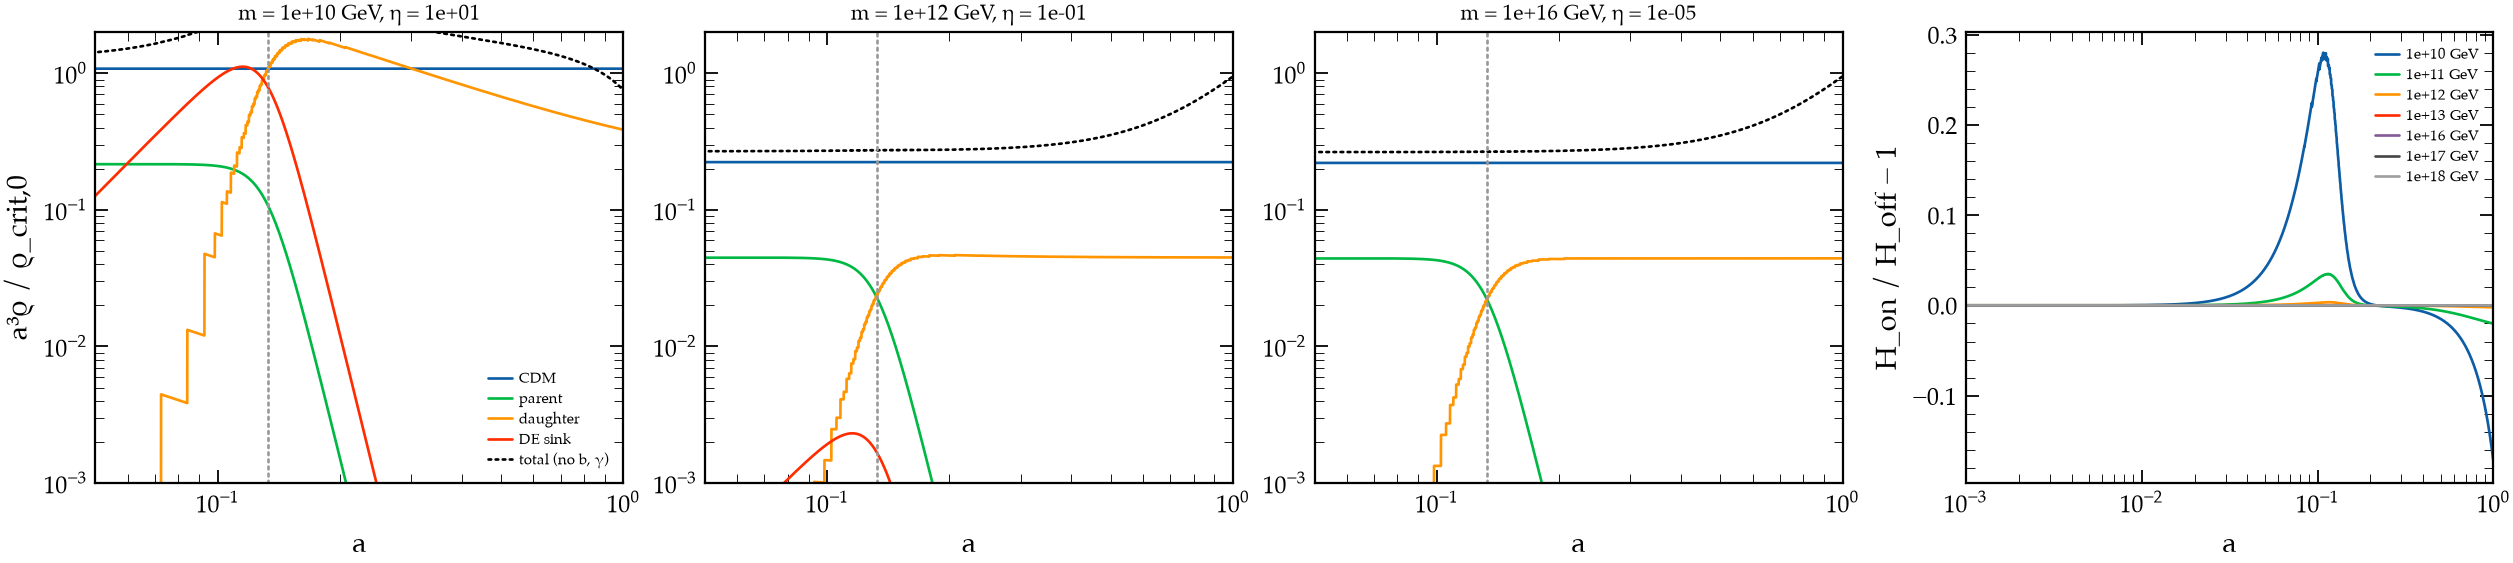

In [3]:
def sorted_bg(r):
    bg = r['bg']
    a = 1/(1 + bg['z'])
    o = np.argsort(a)
    return a[o], {k: v[o] for k, v in bg.items()}


SHOW = [m for m in (1e10, 1e12, 1e16) if m in done]
fig, axes = plt.subplots(1, len(SHOW) + 1, figsize=(4.2*(len(SHOW) + 1), 3.8), constrained_layout=True)
for ax, m in zip(axes, SHOW):
    a, b = sorted_bg(runs[(m, True)])
    norm = a**3/b['(.)rho_crit'][-1]
    for key, label in (('(.)rho_cdm', 'CDM'), ('(.)rho_acc_cdm', 'parent'), ('(.)rho_ncdm[1]', 'daughter'),
                       ('(.)rho_de_acc', 'DE sink')):
        ax.loglog(a, np.where(b[key] > 0, b[key]*norm, np.nan), label=label)
    total = sum(b[k] for k in ('(.)rho_cdm', '(.)rho_acc_cdm', '(.)rho_ncdm[1]', '(.)rho_lambda', '(.)rho_de_acc'))
    ax.loglog(a, total*norm, 'k:', label='total (no b, γ)')
    ax.set_xlim(5e-2, 1)
    ax.set_ylim(1e-3, 2)
    ax.axvline(A_T, color='0.6', ls=':')
    ax.set_title('m = {:.0e} GeV, η = {:.0e}'.format(m, 1e11/m), fontsize=10)
    ax.set_xlabel('a')
axes[0].set_ylabel('a³ρ / ρ_crit,0')
axes[0].legend(fontsize=7)
for m in done:
    a, b = sorted_bg(runs[(m, True)])
    a0, b0 = sorted_bg(runs[(m, False)])
    axes[-1].semilogx(a, b['H [1/Mpc]']/np.interp(np.log(a), np.log(a0), b0['H [1/Mpc]']) - 1,
                      label='{:.0e} GeV'.format(m))
axes[-1].set_xlim(1e-3, 1)
axes[-1].set_xlabel('a')
axes[-1].set_ylabel('H_on / H_off − 1')
axes[-1].legend(fontsize=7)
plt.show()

## CMB

Relative differences of the lensed spectra; TE is normalized by √(C_ℓ^TT C_ℓ^EE) because it crosses
zero. Grey: cosmic variance √(2/(2ℓ+1)).

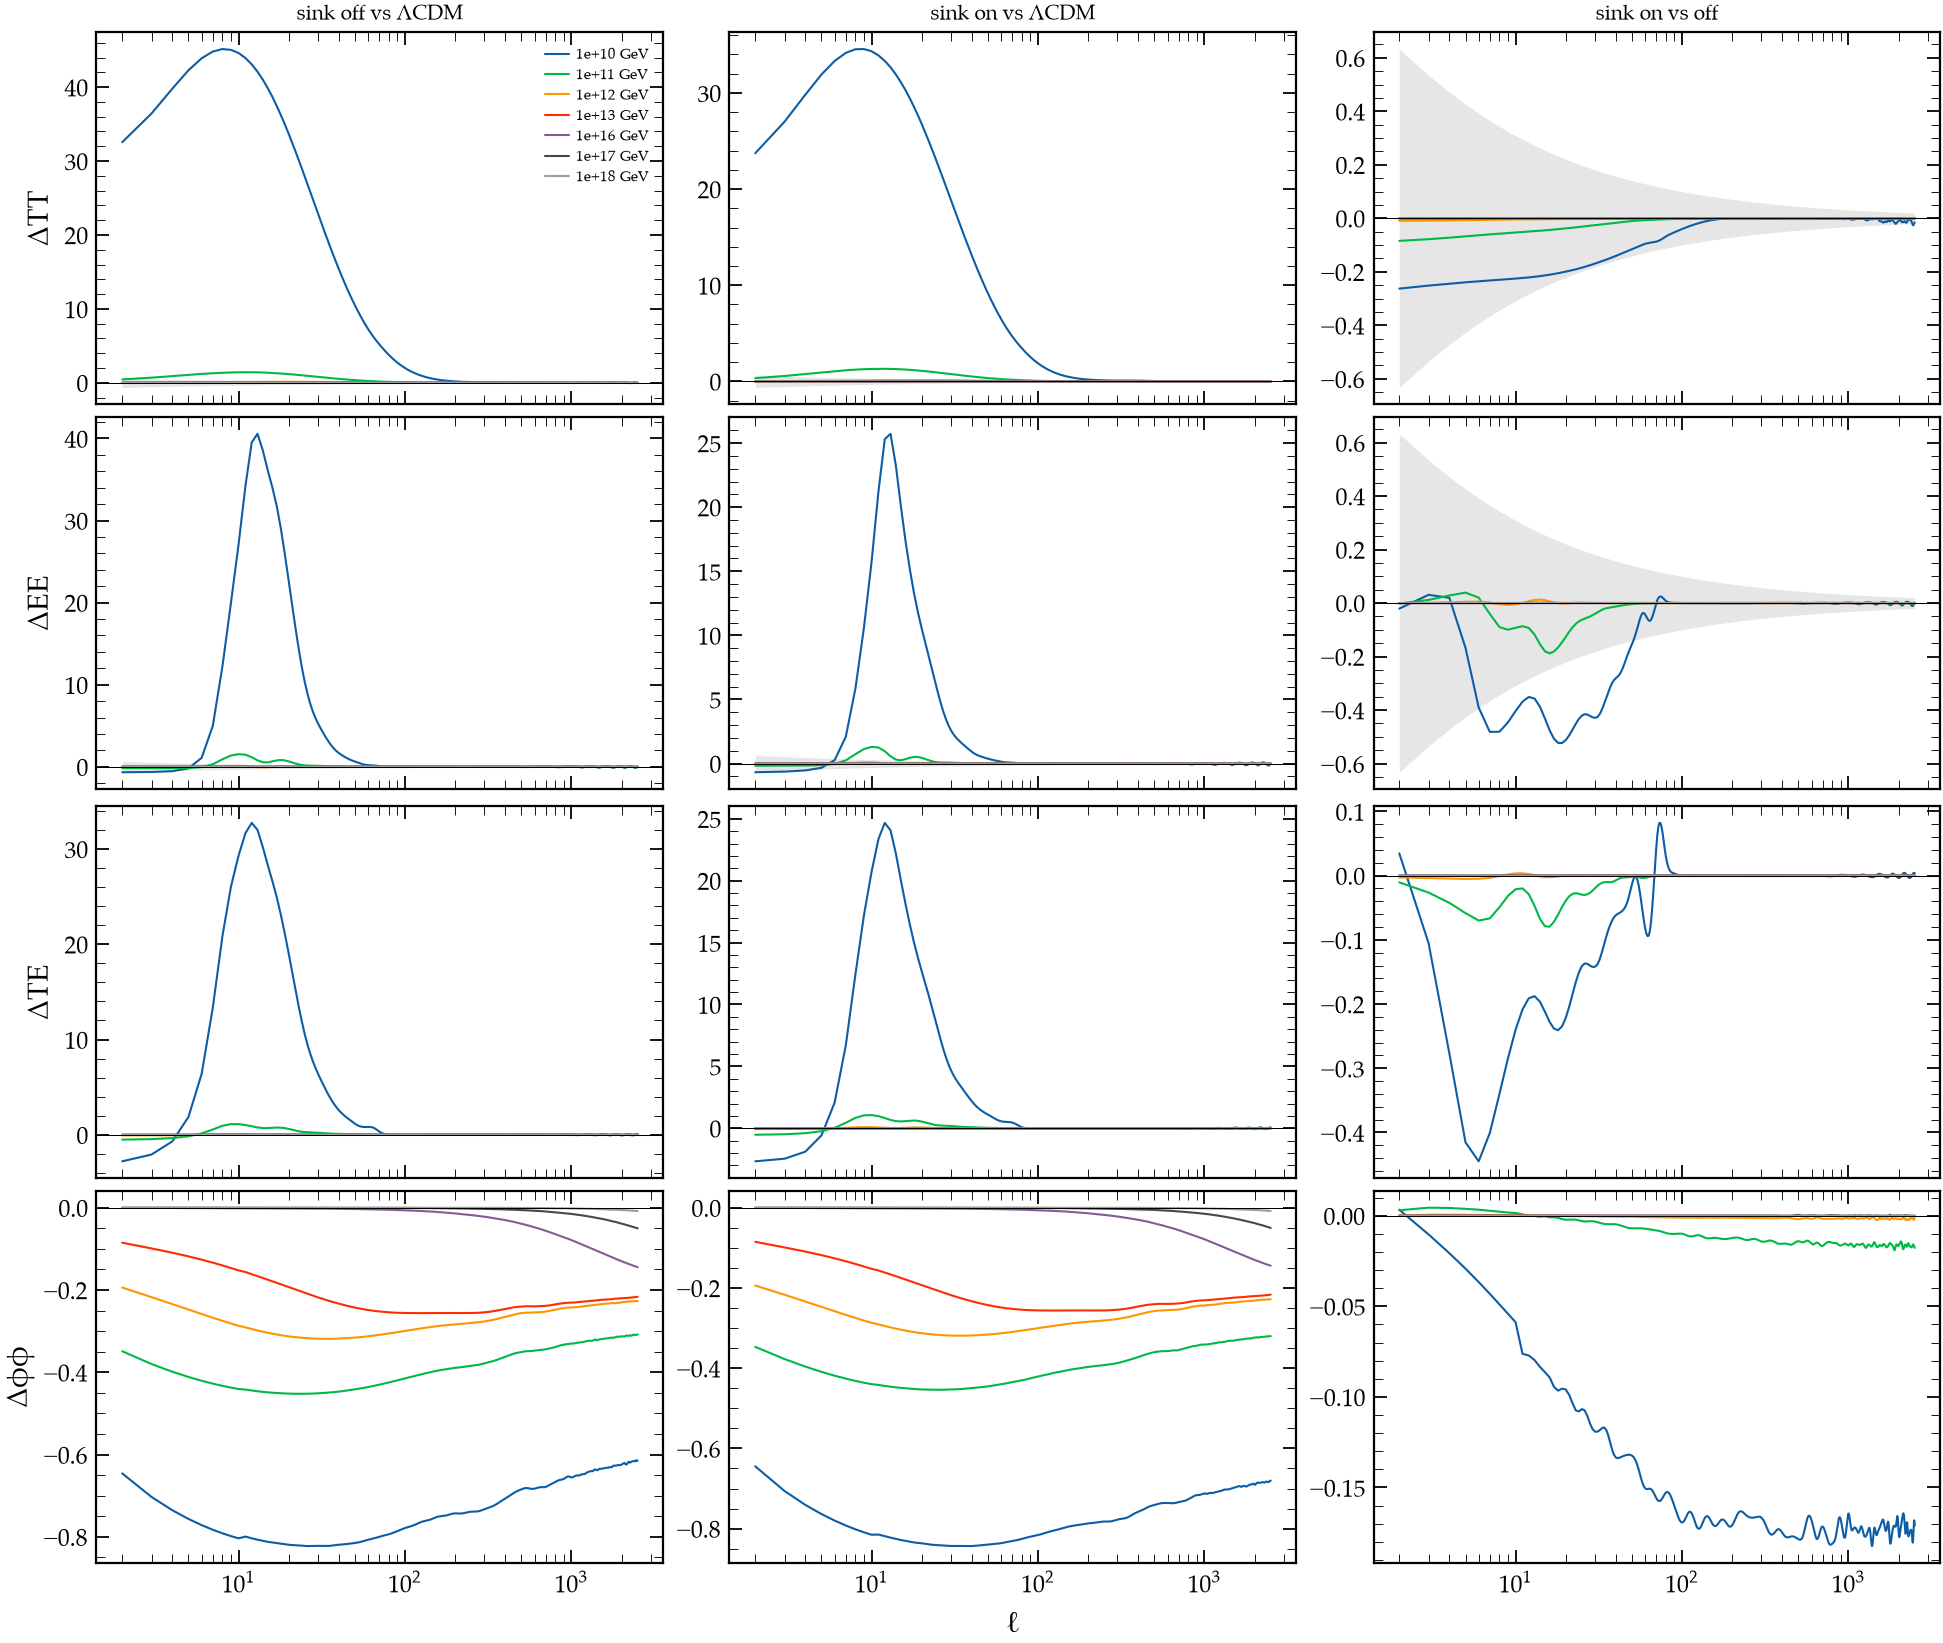

In [4]:
ell = np.arange(2, LMAX + 1)
cv = np.sqrt(2/(2*ell + 1))


def delta(x, y, s):
    return (x['te'] - y['te'])/np.sqrt(y['tt']*y['ee']) if s == 'te' else x[s]/y[s] - 1


COLS = [('sink off vs ΛCDM', lambda m: (runs[(m, False)], runs['lcdm'])),
        ('sink on vs ΛCDM', lambda m: (runs[(m, True)], runs['lcdm'])),
        ('sink on vs off', lambda m: (runs[(m, True)], runs[(m, False)]))]
fig, axes = plt.subplots(4, 3, figsize=(13, 11), sharex=True, constrained_layout=True)
for i, (s, name) in enumerate([('tt', 'TT'), ('ee', 'EE'), ('te', 'TE'), ('pp', 'φφ')]):
    for j, (title, pair) in enumerate(COLS):
        ax = axes[i, j]
        if s in ('tt', 'ee'):
            ax.fill_between(ell, -cv, cv, color='0.9', lw=0)
        for m in done:
            ax.plot(ell, delta(*pair(m), s), lw=1, label='{:.0e} GeV'.format(m))
        ax.axhline(0, color='k', lw=0.5)
        ax.set_xscale('log')
        if i == 0:
            ax.set_title(title, fontsize=10)
        if j == 0:
            ax.set_ylabel('Δ' + name)
axes[-1, 1].set_xlabel('ℓ')
axes[0, 0].legend(fontsize=7)
plt.show()

## P(k) at z = 0

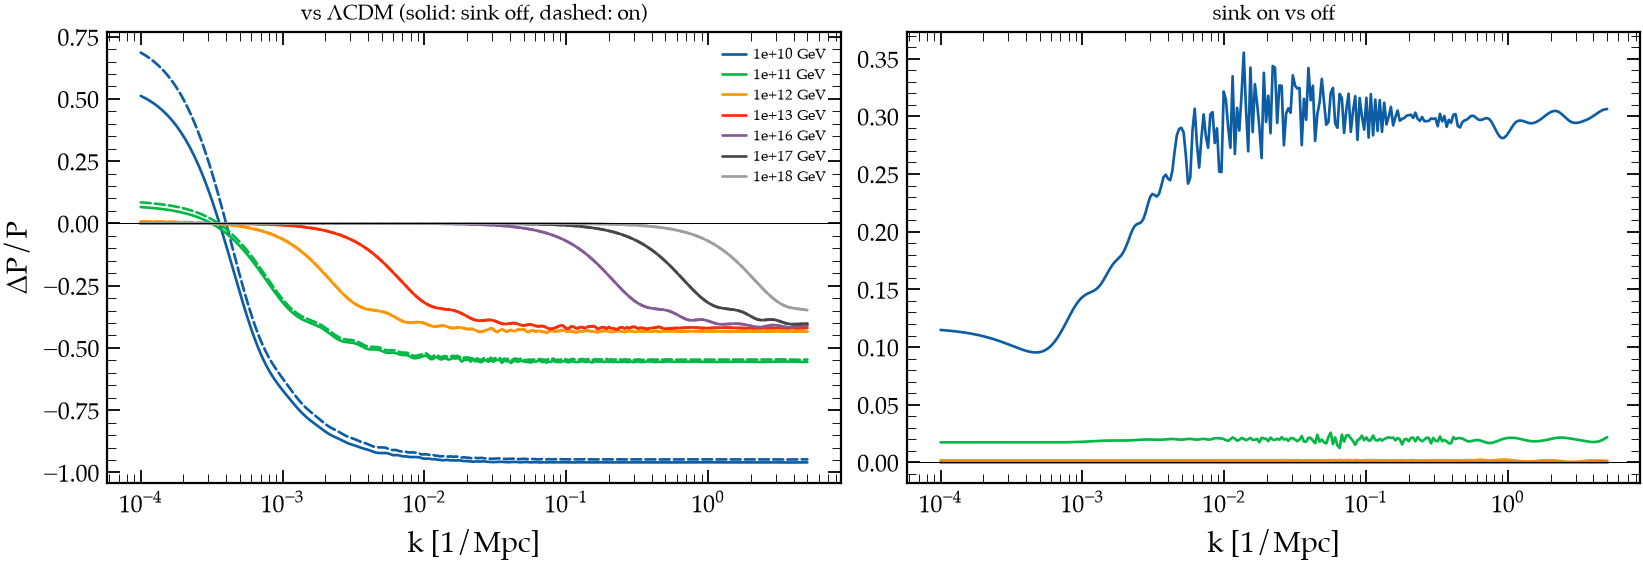

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for m in done:
    p_off, p_on = runs[(m, False)]['pk'], runs[(m, True)]['pk']
    line, = axes[0].semilogx(K, p_off/runs['lcdm']['pk'] - 1, label='{:.0e} GeV'.format(m))
    axes[0].semilogx(K, p_on/runs['lcdm']['pk'] - 1, ls='--', color=line.get_color())
    axes[1].semilogx(K, p_on/p_off - 1, color=line.get_color())
axes[0].set_title('vs ΛCDM (solid: sink off, dashed: on)', fontsize=10)
axes[1].set_title('sink on vs off', fontsize=10)
for ax in axes:
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('k [1/Mpc]')
axes[0].set_ylabel('ΔP/P')
axes[0].legend(fontsize=7)
plt.show()

In [6]:
free = 'H0' if FIX == '100*theta_s' else '100*theta_s'
value = (lambda r: 100*r['h']) if free == 'H0' else (lambda r: r['100*theta_s'])
rows = []
for m in done:
    off, on = runs[(m, False)], runs[(m, True)]
    _, b = sorted_bg(on)
    rows.append({'mass [GeV]': m, 'eta': 1e11/m, 'max Ω_de_acc': b['(.)rho_de_acc'].max()/b['(.)rho_crit'][-1],
                 free + ' off': value(off), free + ' on': value(on), 'sigma8 off': off['sigma8'],
                 'sigma8 on': on['sigma8'], 'max ΔTT on/off': np.max(np.abs(on['tt']/off['tt'] - 1))})
print('{} fixed; ΛCDM: {} = {:.4f}, sigma8 = {:.4f}'.format(FIX, free, value(runs['lcdm']), runs['lcdm']['sigma8']))
show(pd.DataFrame(rows).set_index('mass [GeV]'),
     {'eta': '{:.0e}', 'max Ω_de_acc': '{:.2e}', 'max ΔTT on/off': '{:.1e}'}, default='{:.4f}')

100*theta_s fixed; ΛCDM: H0 = 67.3534, sigma8 = 0.8132


,eta,max Ω_de_acc,H0 off,H0 on,sigma8 off,sigma8 on,max ΔTT on/off
mass [GeV],,,,,,,
1.000000e+10,1e+01,1.02e+03,36.8483,30.4364,0.1049,0.1024,2.6e-01
1.000000e+11,1e+00,2.39e+01,64.0910,62.7886,0.5240,0.5217,8.4e-02
1.000000e+12,1e-01,2.11e+00,67.0600,66.9172,0.6105,0.6102,9.5e-03
1.000000e+13,1e-02,2.08e-01,67.3244,67.3100,0.6222,0.6222,9.2e-04
1.000000e+16,1e-05,2.08e-04,67.3532,67.3532,0.7671,0.7671,1.6e-06
1.000000e+17,1e-06,2.08e-05,67.3532,67.3532,0.8065,0.8065,7.3e-04
1.000000e+18,1e-07,2.08e-06,67.3533,67.3533,0.8125,0.8125,1.7e-06
